# 04 — Appendix experiments

Experiments outside the main story (`02_results`), each changing **one thing** in the protocol and rerunning every
tested model with otherwise identical settings (`python -m src.train <model> <input> --<option>`; results in their own
folder under `outputs/results/`).

1. **Non-overlapping windows** — training stride 150 instead of 10.
2. **Unseen recordings** — protocol B (the papers' held-out recordings).

## 0. Setup

In [1]:
import sys; sys.path.insert(0, "..")
import json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from src.data import LEGS, labels, load_recordings, split

RESULTS = Path("../outputs/results")
MODELS = ["ridge_current", "ridge_window_log", "ridge_feat_all", "svm_linear_feat_all", "krr_feat_all",
          "svm_rbf_feat_all", "tree_feat_all", "rf_feat_all", "gb_feat_all"]
SHORT = {"ridge_current": "ridge, current", "ridge_window_log": "ridge, window", "ridge_feat_all": "ridge, features",
         "svm_linear_feat_all": "linear SVM", "krr_feat_all": "kernel ridge", "svm_rbf_feat_all": "RBF SVM",
         "tree_feat_all": "decision tree", "rf_feat_all": "random forest", "gb_feat_all": "gradient boosting"}
recs = load_recordings()

def load(folder=""):
    """{model: (result json, test predictions)} for the runs saved in outputs/results/<folder>."""
    d = RESULTS / folder
    return {m: (json.loads((d / f"{m}.json").read_text()), np.load(d / f"{m}_test_pred.npy"))
            for m in MODELS if (d / f"{m}.json").exists()}

def rates(p, y):
    return {"false contact": ((p == 1) & (y == 0)).sum() / (y == 0).sum(),
            "missed contact": ((p == 0) & (y == 1)).sum() / (y == 1).sum()}

def per_recording(p, ends, y):
    """Test F1 per ground recording; false-contact rate for the air recordings."""
    out, i = {}, 0
    for name, e in ends.items():
        yy, q = y[i:i + len(e)], p[i:i + len(e)]
        i += len(e)
        out[name] = (np.mean([f1_score(yy[:, k], q[:, k], zero_division=0) for k in range(4)])
                     if yy.any() else q.mean())
    return pd.Series(out)

def best_params(r):
    b = max(r["validation"], key=lambda v: v["val_f1"])
    return ", ".join(f"{k.split('__')[-1]}={v:g}" if not isinstance(v, str) else f"{k.split('__')[-1]}={v}"
                     for k, v in b["params"].items())

## 1. Non-overlapping windows (training stride 150)

Same split, models, grids and refit as the main results; **train and validation windows taken every 150 steps instead of
every 10** — consecutive windows no longer overlap. Test unchanged (every timestep).
- Train / val / refit windows: 4,707 / 997 / 5,704 (stride 10: 70,476 / 14,882 / 85,358).
- Kernel models were already capped at 10k windows; now **every model sees the same 5.7k windows** (the `_10k`
  references would be identical to the full models and are not rerun).
- Validation has 997 windows instead of 14,882 → noisier selection; validation scores are not comparable across strides.

In [2]:
test_ends = split(recs)["test"]
y_test = labels(recs, test_ends)
s10, s150 = load(), load("stride150")
refit_windows = {m: (10_000 if m in ("krr_feat_all", "svm_rbf_feat_all") else 85_358) for m in MODELS}
cmp = pd.DataFrame({SHORT[m]: {
    "refit windows (stride 10)": refit_windows[m], "refit windows (stride 150)": 5_704,
    "F1 stride 10": s10[m][0]["test"]["f1"], "F1 stride 150": s150[m][0]["test"]["f1"],
    "change [points]": 100 * (s150[m][0]["test"]["f1"] - s10[m][0]["test"]["f1"]),
    **{f"{k} (10)": v for k, v in rates(s10[m][1], y_test).items()},
    **{f"{k} (150)": v for k, v in rates(s150[m][1], y_test).items()}} for m in MODELS}).T
cmp.round(4)

,refit windows (stride 10),refit windows (stride 150),F1 stride 10,F1 stride 150,change [points],false contact (10),missed contact (10),false contact (150),missed contact (150)
"ridge, current",85358.0,5704.0,0.8404,0.8373,-0.3129,0.0601,0.1888,0.0608,0.1930
"ridge, window",85358.0,5704.0,0.9297,0.9211,-0.8584,0.0327,0.0749,0.0345,0.0878
"ridge, features",85358.0,5704.0,0.9463,0.9418,-0.4523,0.0317,0.0455,0.0332,0.0514
linear SVM,85358.0,5704.0,0.9519,0.9389,-1.3007,0.0278,0.0417,0.0363,0.0514
kernel ridge,10000.0,5704.0,0.9558,0.9529,-0.2825,0.0249,0.0395,0.0275,0.0402
RBF SVM,10000.0,5704.0,0.9528,0.9486,-0.4269,0.0273,0.0408,0.0276,0.0483
decision tree,85358.0,5704.0,0.9396,0.8981,-4.1498,0.0315,0.0585,0.0554,0.0953
random forest,85358.0,5704.0,0.9668,0.9521,-1.4677,0.0177,0.0315,0.0234,0.0492
gradient boosting,85358.0,5704.0,0.9720,0.9583,-1.3692,0.0160,0.0244,0.0229,0.0381


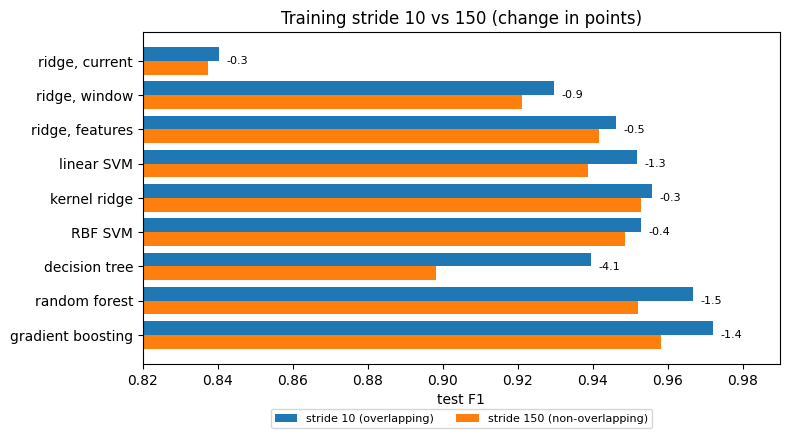

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
yy = np.arange(len(cmp))
ax.barh(yy - 0.2, cmp["F1 stride 10"], 0.4, label="stride 10 (overlapping)")
ax.barh(yy + 0.2, cmp["F1 stride 150"], 0.4, label="stride 150 (non-overlapping)")
for i, (a, b) in enumerate(zip(cmp["F1 stride 10"], cmp["F1 stride 150"])):
    ax.text(max(a, b) + 0.002, i, f"{100 * (b - a):+.1f}", va="center", fontsize=8)
ax.set_yticks(yy, cmp.index); ax.invert_yaxis(); ax.set_xlim(0.82, 0.99); ax.set_xlabel("test F1")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=8); ax.set_title("Training stride 10 vs 150 (change in points)")
plt.tight_layout(); plt.show()

In [4]:
pd.DataFrame({SHORT[m]: {"stride 10": best_params(s10[m][0]), "stride 150": best_params(s150[m][0])}
              for m in MODELS}).T.rename_axis("chosen hyperparameters")

,stride 10,stride 150
chosen hyperparameters,,
"ridge, current",alpha=0.001,alpha=0.01
"ridge, window",alpha=0.1,alpha=10
"ridge, features",alpha=0.1,alpha=10
linear SVM,C=0.3,C=0.01
kernel ridge,"alpha=0.03, gamma_scale=0.3","alpha=0.1, gamma_scale=0.2"
RBF SVM,"C=10, gamma_scale=0.3","C=10, gamma_scale=0.3"
decision tree,min_samples_leaf=50,min_samples_leaf=1
random forest,"max_features=0.1, min_samples_leaf=1","max_features=0.2, min_samples_leaf=1"
gradient boosting,"max_iter=800, max_leaf_nodes=63","max_iter=400, max_leaf_nodes=63"


In [5]:
# change per recording (test F1 points; air recordings: change in false-contact rate)
sel = ["ridge_feat_all", "krr_feat_all", "tree_feat_all", "rf_feat_all", "gb_feat_all"]
(100 * pd.DataFrame({SHORT[m]: per_recording(s150[m][1], test_ends, y_test) - per_recording(s10[m][1], test_ends, y_test)
                     for m in sel})).round(1)

,"ridge, features",kernel ridge,decision tree,random forest,gradient boosting
air_jumping_gait,0.0,0.0,0.6,0.0,0.0
air_walking_gait,0.2,0.0,3.7,0.0,0.0
asphalt_road,0.2,0.3,-2.7,-0.6,-1.2
old_asphalt_road,-0.4,-0.4,-5.0,-1.3,-2.0
concrete_difficult_slippery,-0.6,-0.4,-4.7,-0.7,-0.9
concrete_galloping,-1.4,-1.4,-8.7,-9.2,-5.7
concrete_left_circle,-0.0,-0.3,-1.6,-0.5,-0.5
concrete_pronking,-0.6,-0.0,-4.7,-1.0,-0.6
concrete_right_circle,-0.2,-0.2,-1.7,-0.9,-0.8
forest,-0.8,-0.0,-3.3,-1.3,-1.5


- **Every model loses with non-overlapping windows**: from −0.3 (kernel ridge, ridge on the current timestep) to −4.1
  points (single tree). The 90% "redundant" overlapping windows are not harmless duplicates — they are free extra data.
- **The loss follows how much data a model used and how much it can use**:
  - kernel models lose little (−0.3 / −0.4): they already had only 10k windows (now 5.7k, ×0.57);
  - ridge loses little despite 15× fewer windows (−0.3 to −0.9): a linear boundary needs few samples;
  - the data-hungry models lose most: linear SVM −1.3 (the hinge is decided by the windows near the boundary — the same
    model gained +1.0 from 10k → 70k), random forest −1.5, boosting −1.4, single tree −4.1.
- **Ranking at stride 150**: boosting still best (0.958), but kernel ridge (0.953) and the forest (0.952) close in —
  boosting's lead over kernel ridge drops from 1.6 to 0.5 points, consistent with the main results, where ~1.0 of
  that lead came from the extra data (`gb_10k`).
- **Both errors grow**, false contacts too: boosting 1.6% → 2.3%, forest 1.8% → 2.3%, single tree 3.2% → 5.5%.
- **Galloping suffers most** (forest −9.2, tree −8.7, boosting −5.7, ridge and kernel ridge −1.4): the only
  galloping recording, so at stride 150 the whole gait is learned from ~230 training windows.
- **With less data, validation picks stronger regularization**: ridge α 0.1 → 10, linear SVM C 0.3 → 0.01 (smaller C =
  stronger), kernel ridge α 0.03 → 0.1 with a smoother kernel (s 0.3 → 0.2), boosting 800 → 400 trees. RBF SVM
  unchanged. The single tree goes the other way (leaf size 50 → 1): with 5.7k windows and no near-duplicates, leaves
  of 50 are too coarse.
- **Conclusion**: confirms the Phase 2 choice — overlapping windows (stride 10) cost nothing and help every model, most
  of all the flexible ones; non-overlapping windows only lose information.

## 2. Unseen recordings — protocol B

The papers' split: test = every window of `air_jumping_gait`, `concrete_pronking`, `concrete_right_circle`, `forest`,
`small_pebble` (never seen in training); the other 10 recordings → first 85% train, gap, last 15% validation
(`split_b`, `src/data.py`). Same models, grids and refit as protocol A.

*Results pending (`--protocol-b`, stride 150 first).*